In [2]:
!git clone https://github.com/Akinloye3264/Formative_3_Machine_Learning.git
%cd Formative_3_Machine_Learning
!ls

Cloning into 'Formative_3_Machine_Learning'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 47 (delta 18), reused 27 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 26.88 MiB | 23.93 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/Formative_3_Machine_Learning/Formative_3_Machine_Learning
 bayesian
'BSE Group Assignments _ Task Sheet_[Math For Machine Learning_Probability Distributions, Bayesian Probability, and Gradient Descent Implementation_Cohort 1_Team4] - 1.pdf'
 Em_gmm_heights.py
 Formative3-Part3.pdf
 GaltonFamilies.csv
 Gradient.py
 README.md


# Part 1 — EM Algorithm (Gaussian Mixture Model)

We separate a set of unlabelled heights into two groups (children and adults) using Expectation-Maximization. We do not split at the global mean because a hard cut-off misclassifies the overlap and ignores that the two groups have different spreads. Instead EM assigns each point a probability of belonging to each group, then refines those estimates until the log-likelihood stops improving.

In [3]:
import numpy as np

DATA_PATH = "GaltonFamilies.csv"

header = np.genfromtxt(DATA_PATH, delimiter=',', dtype=str, max_rows=1)
col = {name: i for i, name in enumerate(header)}
rows = np.genfromtxt(DATA_PATH, delimiter=',', dtype=str, skip_header=1)

family = rows[:, col["family"]]
father = rows[:, col["father"]].astype(float)
child_heights = rows[:, col["childHeight"]].astype(float)

_, first_idx = np.unique(family, return_index=True)
father_heights = father[first_idx]

X = np.concatenate([child_heights, father_heights])
rng = np.random.default_rng(42)
rng.shuffle(X)
n = len(X)

print(f"Pooled, unlabeled data points: {n} "
      f"(children: {len(child_heights)}, fathers: {len(father_heights)})")
print(f"Global mean: {X.mean():.3f}, Global std: {X.std():.3f}\n")

Pooled, unlabeled data points: 1139 (children: 934, fathers: 205)
Global mean: 67.209, Global std: 3.567



In [4]:
def gaussian_pdf(x, mu, sigma2):
    """Normal density: how likely is height x under this curve?"""
    sigma2 = max(sigma2, 1e-6)
    return (1.0 / np.sqrt(2 * np.pi * sigma2)) * np.exp(-((x - mu) ** 2) / (2 * sigma2))


def log_likelihood(X, mu1, mu2, s1, s2, pi1, pi2):
    mix = pi1 * gaussian_pdf(X, mu1, s1) + pi2 * gaussian_pdf(X, mu2, s2)
    return np.sum(np.log(np.clip(mix, 1e-300, None)))


def e_step(X, mu1, mu2, s1, s2, pi1, pi2):
    """Responsibilities gamma_i = P(component | x_i) via Bayes' rule."""
    p1 = pi1 * gaussian_pdf(X, mu1, s1)
    p2 = pi2 * gaussian_pdf(X, mu2, s2)
    total = np.clip(p1 + p2, 1e-300, None)
    return p1 / total, p2 / total


def m_step(X, gamma1, gamma2):
    """Re-estimate mu, sigma^2, pi as responsibility-weighted averages."""
    N1, N2 = gamma1.sum(), gamma2.sum()
    mu1 = np.sum(gamma1 * X) / N1
    mu2 = np.sum(gamma2 * X) / N2
    s1 = np.sum(gamma1 * (X - mu1) ** 2) / N1
    s2 = np.sum(gamma2 * (X - mu2) ** 2) / N2
    pi1, pi2 = N1 / len(X), N2 / len(X)
    return mu1, mu2, s1, s2, pi1, pi2

In [5]:
# Initialization: means at 25th/75th percentiles so one starts low, one high
mu1, mu2 = np.percentile(X, 25), np.percentile(X, 75)
s1 = s2 = np.var(X)
pi1 = pi2 = 0.5

history = [(0, mu1, mu2, s1, s2, pi1, pi2,
            log_likelihood(X, mu1, mu2, s1, s2, pi1, pi2))]

MAX_ITERS, TOL = 100, 1e-6
for it in range(1, MAX_ITERS + 1):
    gamma1, gamma2 = e_step(X, mu1, mu2, s1, s2, pi1, pi2)
    mu1, mu2, s1, s2, pi1, pi2 = m_step(X, gamma1, gamma2)
    ll_new = log_likelihood(X, mu1, mu2, s1, s2, pi1, pi2)
    history.append((it, mu1, mu2, s1, s2, pi1, pi2, ll_new))
    if abs(ll_new - history[-2][-1]) < TOL:
        break

# Tracking table: initialization + first 2 iterations
print(f"{'Iter':<10}{'mu1(Child)':<12}{'mu2(Adult)':<12}"
      f"{'sigma1^2':<12}{'sigma2^2':<12}{'pi1':<9}{'pi2':<9}{'LogLik':<12}")
for row in history[:3]:
    it, m1, m2, v1, v2, p1, p2, l = row
    label = "0 (Init)" if it == 0 else str(it)
    print(f"{label:<10}{m1:<12.4f}{m2:<12.4f}{v1:<12.4f}"
          f"{v2:<12.4f}{p1:<9.4f}{p2:<9.4f}{l:<12.2f}")

_, mu1f, mu2f, s1f, s2f, pi1f, pi2f, llf = history[-1]
print(f"\nConverged at iteration {history[-1][0]}")
print(f"Children -> mu={mu1f:.3f}, sigma={np.sqrt(s1f):.3f}, pi={pi1f:.3f}")
print(f"Adults   -> mu={mu2f:.3f}, sigma={np.sqrt(s2f):.3f}, pi={pi2f:.3f}")

Iter      mu1(Child)  mu2(Adult)  sigma1^2    sigma2^2    pi1      pi2      LogLik      
0 (Init)  64.5000     70.0000     12.7241     12.7241     0.5000   0.5000   -3119.82    
1         65.2205     69.2054     9.0603      8.4468      0.5011   0.4989   -3057.91    
2         65.1609     69.2600     8.9420      8.1040      0.5005   0.4995   -3056.97    

Converged at iteration 100
Children -> mu=64.273, sigma=2.341, pi=0.449
Adults   -> mu=69.605, sigma=2.420, pi=0.551


h= 50.0 -> P(Child)=1.0000, P(Adult)=0.0000  =>  CHILD
h= 60.0 -> P(Child)=0.9976, P(Adult)=0.0024  =>  CHILD
h= 68.0 -> P(Child)=0.2284, P(Adult)=0.7716  =>  ADULT


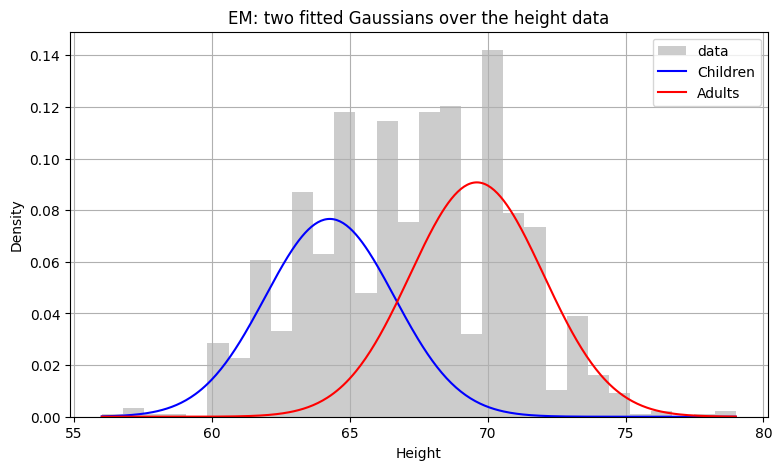

In [6]:
import matplotlib.pyplot as plt

def classify_height(h, mu1, mu2, s1, s2, pi1, pi2):
    p_child = pi1 * gaussian_pdf(h, mu1, s1)
    p_adult = pi2 * gaussian_pdf(h, mu2, s2)
    total = p_child + p_adult
    return p_child / total, p_adult / total


for h in [50.0, 60.0, 68.0]:
    pc, pa = classify_height(h, mu1f, mu2f, s1f, s2f, pi1f, pi2f)
    print(f"h={h:5.1f} -> P(Child)={pc:.4f}, P(Adult)={pa:.4f}  =>  "
          f"{'CHILD' if pc > pa else 'ADULT'}")

# Visualise the two fitted Gaussians over the data
xs = np.linspace(X.min(), X.max(), 400)
plt.figure(figsize=(9, 5))
plt.hist(X, bins=30, density=True, alpha=0.4, color='gray', label='data')
plt.plot(xs, pi1f * gaussian_pdf(xs, mu1f, s1f), 'b-', label='Children')
plt.plot(xs, pi2f * gaussian_pdf(xs, mu2f, s2f), 'r-', label='Adults')
plt.title('EM: two fitted Gaussians over the height data')
plt.xlabel('Height'); plt.ylabel('Density'); plt.legend(); plt.grid(True)
plt.show()

# Part 2 — Bayesian Probability (IMDb Sentiment)

For each keyword we compute P(Positive | keyword) using Bayes' theorem, in pure Python. We report the prior P(Positive), likelihood P(keyword|Positive), marginal P(keyword), and posterior P(Positive|keyword). Positive keywords score near 1 and negative keywords near 0.

In [7]:
def read_records(path):
    with open(path, encoding="utf-8") as f:
        content = f.read()
    fields, field, in_quotes, i = [], "", False, 0
    n, records = len(content), []
    while i < n:
        char = content[i]
        if in_quotes:
            if char == '"':
                if i + 1 < n and content[i + 1] == '"':
                    field += '"'; i += 2; continue
                in_quotes = False; i += 1
            else:
                field += char; i += 1
        else:
            if char == '"':
                in_quotes = True; i += 1
            elif char == ",":
                fields.append(field); field = ""; i += 1
            elif char == "\n":
                fields.append(field); records.append(fields)
                fields, field = [], ""; i += 1
            elif char == "\r":
                i += 1
            else:
                field += char; i += 1
    if field or fields:
        fields.append(field); records.append(fields)
    return records


def tokenize(text):
    text = text.lower().replace("<br />", " ").replace("<br/>", " ").replace("<br>", " ")
    words, current = set(), ""
    for char in text:
        if char.isalpha() or char == "'":
            current += char
        else:
            if current:
                words.add(current); current = ""
    if current:
        words.add(current)
    return words


def build_counts(path):
    records = read_records(path)
    header = records[0]
    text_idx = header.index("review")
    label_idx = header.index("sentiment")
    n_total = n_positive = 0
    pos_word_counts, all_word_counts = {}, {}
    for row in records[1:]:
        if len(row) <= max(text_idx, label_idx):
            continue
        label = row[label_idx].strip().lower()
        words = tokenize(row[text_idx])
        n_total += 1
        for word in words:
            all_word_counts[word] = all_word_counts.get(word, 0) + 1
        if label == "positive":
            n_positive += 1
            for word in words:
                pos_word_counts[word] = pos_word_counts.get(word, 0) + 1
    return n_total, n_positive, pos_word_counts, all_word_counts


def bayes_positive_given_keyword(keyword, n_total, n_positive,
                                 pos_word_counts, all_word_counts):
    keyword = keyword.lower()
    prior = n_positive / n_total
    likelihood = pos_word_counts.get(keyword, 0) / n_positive
    marginal = all_word_counts.get(keyword, 0) / n_total
    posterior = 0.0 if marginal == 0 else (likelihood * prior) / marginal
    return prior, likelihood, marginal, posterior

In [8]:
positive_keywords = ["brilliant", "masterpiece", "wonderful", "excellent"]
negative_keywords = ["boring", "terrible", "waste", "awful"]

n_total, n_positive, pos_counts, all_counts = build_counts("bayesian/IMDB_Dataset.csv")
print(f"Loaded {n_total} reviews ({n_positive} positive)\n")

hdr = ("Keyword".ljust(12) + "Prior".rjust(9) + "Likelihood".rjust(12)
       + "Marginal".rjust(10) + "Posterior".rjust(11))
print(hdr); print("-" * len(hdr))

for keyword in positive_keywords + negative_keywords:
    prior, likelihood, marginal, posterior = bayes_positive_given_keyword(
        keyword, n_total, n_positive, pos_counts, all_counts)
    print(keyword.ljust(12)
          + ("%.4f" % prior).rjust(9)
          + ("%.4f" % likelihood).rjust(12)
          + ("%.4f" % marginal).rjust(10)
          + ("%.4f" % posterior).rjust(11))

Loaded 50000 reviews (25000 positive)

Keyword         Prior  Likelihood  Marginal  Posterior
------------------------------------------------------
brilliant      0.5000      0.0634    0.0417     0.7606
masterpiece    0.5000      0.0350    0.0240     0.7300
wonderful      0.5000      0.0902    0.0555     0.8120
excellent      0.5000      0.1146    0.0710     0.8073
boring         0.5000      0.0236    0.0610     0.1938
terrible       0.5000      0.0152    0.0539     0.1413
waste          0.5000      0.0070    0.0507     0.0687
awful          0.5000      0.0112    0.0575     0.0977


# Part 3 — Manual Gradient Descent

We fit y = m1*x1 + m2*x2 + b to two data points by hand, using matrix multiplication, over four iterations. Setup: X = [[1,3],[4,10]], y = [5,6], initial m = [-1,2], b = 1, learning rate = 0.001. The handwritten calculations are in Formative3-Part3.pdf in the repository.

| Iter | m1 | m2 | b | MSE |
|------|------|------|------|------|
| 0 (start) | -1.000 | 2.000 | 1.000 | 61.00 |
| 1 | -1.045 | 1.887 | 0.988 | 47.01 |
| 2 | -1.084 | 1.788 | 0.978 | 36.37 |
| 3 | -1.119 | 1.702 | 0.969 | 28.26 |
| 4 | -1.149 | 1.627 | 0.962 | 22.09 |

The error falls steadily from 61 to 22, so m and b are moving in a direction that reduces the error.

# Part 4 — Gradient Descent in Code

The same calculation in Python, using SciPy to compute the derivative of the MSE cost, with each step visible. Two plots show how m and b change and how the error falls over the iterations.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.differentiate import derivative

X = np.array([[1, 3], [4, 10]], dtype=float)
Y = np.array([[5], [6]], dtype=float)
m = np.array([[-1.0], [2.0]])
b = 1.0
LEARNING_RATE = 0.001
NUM_ITERATIONS = 4


def predict(X, m, b):
    return X @ m + b

def mse(Y, X, m, b):
    return np.mean((Y - predict(X, m, b)) ** 2)

def scipy_derivative(func, at):
    return derivative(func, at).df

def gradient_wrt_m(Y, X, m, b, j):
    def cost_of_mj(mj_values):
        mj_values = np.asarray(mj_values, dtype=float)
        costs = np.empty_like(mj_values)
        for idx, value in np.ndenumerate(mj_values):
            m_temp = m.copy()
            m_temp[j, 0] = value
            costs[idx] = mse(Y, X, m_temp, b)
        return costs
    return scipy_derivative(cost_of_mj, float(m[j, 0]))

def gradient_wrt_b(Y, X, m, b):
    def cost_of_b(b_values):
        b_values = np.asarray(b_values, dtype=float)
        costs = np.empty_like(b_values)
        for idx, value in np.ndenumerate(b_values):
            costs[idx] = mse(Y, X, m, float(value))
        return costs
    return scipy_derivative(cost_of_b, float(b))


m_history, b_history, error_history = [], [], []
m_history.append(m.flatten().copy())
b_history.append(b)
error_history.append(mse(Y, X, m, b))
print(f"Iteration 0 (start): m = [{m[0,0]:.4f}, {m[1,0]:.4f}], "
      f"b = {b:.4f}, MSE = {error_history[-1]:.4f}")

for iteration in range(NUM_ITERATIONS):
    grad_m = np.array([[gradient_wrt_m(Y, X, m, b, 0)],
                       [gradient_wrt_m(Y, X, m, b, 1)]])
    grad_b = gradient_wrt_b(Y, X, m, b)
    m = m - LEARNING_RATE * grad_m
    b = b - LEARNING_RATE * grad_b
    m_history.append(m.flatten().copy())
    b_history.append(b)
    error_history.append(mse(Y, X, m, b))
    print(f"Iteration {iteration + 1}: m = [{m[0,0]:.4f}, {m[1,0]:.4f}], "
          f"b = {b:.4f}, MSE = {error_history[-1]:.4f}")

print("\nFinal m:", np.round(m.flatten(), 4))
print("Final b:", round(b, 4))
print("Final MSE:", round(mse(Y, X, m, b), 4))
print("Predictions:", np.round(predict(X, m, b).flatten(), 4))

Iteration 0 (start): m = [-1.0000, 2.0000], b = 1.0000, MSE = 61.0000
Iteration 1: m = [-1.0450, 1.8870], b = 0.9880, MSE = 47.0142
Iteration 2: m = [-1.0843, 1.7884], b = 0.9777, MSE = 36.3673
Iteration 3: m = [-1.1187, 1.7024], b = 0.9689, MSE = 28.2619
Iteration 4: m = [-1.1487, 1.6273], b = 0.9615, MSE = 22.0913

Final m: [-1.1487  1.6273]
Final b: 0.9615
Final MSE: 22.0913
Predictions: [ 4.6948 12.64  ]


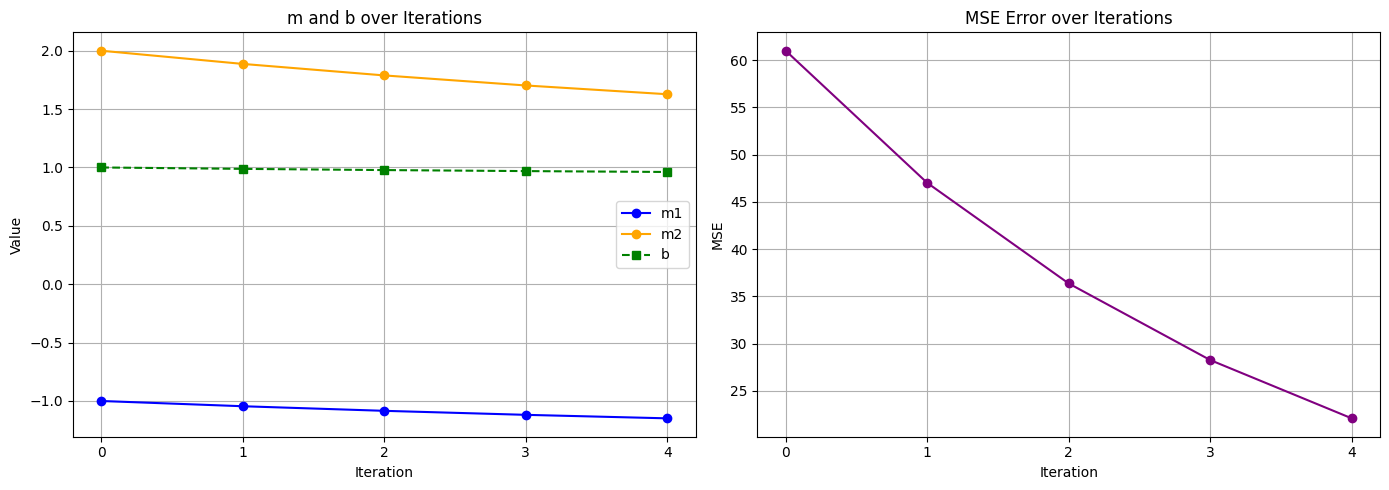

In [4]:
m_hist = np.array(m_history)
iterations = range(0, NUM_ITERATIONS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(iterations, m_hist[:, 0], marker='o', label='m1', color='blue')
axes[0].plot(iterations, m_hist[:, 1], marker='o', label='m2', color='orange')
axes[0].plot(iterations, b_history, marker='s', label='b',
             color='green', linestyle='--')
axes[0].set_title('m and b over Iterations')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Value')
axes[0].set_xticks(list(iterations)); axes[0].legend(); axes[0].grid(True)

axes[1].plot(iterations, error_history, marker='o', color='purple')
axes[1].set_title('MSE Error over Iterations')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('MSE')
axes[1].set_xticks(list(iterations)); axes[1].grid(True)

plt.tight_layout()
plt.show()